# Importing Libraries

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px
from sklearn.model_selection import train_test_split

# load Dataset from data directory

In [83]:
df = pd.read_csv('data/train.csv')

In [84]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,46264,1.457374,tcp,http,FIN,10,16,814,9878,17.154142,...,1,1,1,0,0,1,2,1,0,1
1,3575,0.654355,tcp,-,FIN,10,8,564,354,25.979782,...,1,1,1,0,0,0,1,1,0,1
2,43204,0.000002,udp,-,INT,2,0,1064,0,500000.001300,...,9,1,34,0,0,0,10,33,0,0
3,59869,0.000011,nvp,-,INT,2,0,180,0,90909.090200,...,14,14,14,0,0,0,15,14,0,1
4,1203,0.000004,udp,-,INT,2,0,168,0,250000.000600,...,1,1,1,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65860,718,0.000005,ipv6-opts,-,INT,2,0,200,0,200000.005100,...,2,2,6,0,0,0,2,6,0,1
65861,78596,0.619101,tcp,-,FIN,10,6,586,268,24.228680,...,2,1,7,0,0,0,2,6,0,0
65862,16431,0.513353,tcp,http,FIN,12,26,1620,27492,72.075162,...,1,1,1,0,0,1,19,1,0,1
65863,59007,0.350092,tcp,-,FIN,8,8,364,968,42.845881,...,1,1,2,0,0,0,2,2,0,1


In [85]:
data_dict = pd.read_csv('data/data_dictionary.csv')

In [86]:
print(data_dict)

          column_name                                        description  \
0                  id        Unique identifier of the network connection   
1                 dur                 Duration of the network connection   
2               proto                              Network protocol used   
3             service                               Network service used   
4               state                                   Connection state   
5               spkts                             Number of packets sent   
6               dpkts                         Number of packets received   
7              sbytes                               Number of bytes sent   
8              dbytes                           Number of bytes received   
9                rate                               Connection data rate   
10               sttl           Source to destination time-to-live value   
11               dttl           Destination to source time-to-live value   
12          

# Performing EDA on Dataset

In [87]:
print("First 5 rows of the dataset : ")
print(df.head())

First 5 rows of the dataset : 
      id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0  46264  1.457374   tcp    http   FIN     10     16     814    9878   
1   3575  0.654355   tcp       -   FIN     10      8     564     354   
2  43204  0.000002   udp       -   INT      2      0    1064       0   
3  59869  0.000011   nvp       -   INT      2      0     180       0   
4   1203  0.000004   udp       -   INT      2      0     168       0   

            rate  ...  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
0      17.154142  ...                 1                 1               1   
1      25.979782  ...                 1                 1               1   
2  500000.001300  ...                 9                 1              34   
3   90909.090200  ...                14                14              14   
4  250000.000600  ...                 1                 1               1   

   is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  \


In [88]:
print("Last 5 rows of the dataset : ")
print(df.tail())

Last 5 rows of the dataset : 
          id       dur      proto service state  spkts  dpkts  sbytes  dbytes  \
65860    718  0.000005  ipv6-opts       -   INT      2      0     200       0   
65861  78596  0.619101        tcp       -   FIN     10      6     586     268   
65862  16431  0.513353        tcp    http   FIN     12     26    1620   27492   
65863  59007  0.350092        tcp       -   FIN      8      8     364     968   
65864  74621  1.053994        tcp       -   FIN     10      8    2516     354   

                rate  ...  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
65860  200000.005100  ...                 2                 2               6   
65861      24.228680  ...                 2                 1               7   
65862      72.075162  ...                 1                 1               1   
65863      42.845881  ...                 1                 1               2   
65864      16.129123  ...                 1                 1               3 

In [89]:
print("Shape of the dataset : ", df.shape)

Shape of the dataset :  (65865, 44)


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65865 entries, 0 to 65864
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 65865 non-null  int64  
 1   dur                65865 non-null  float64
 2   proto              65865 non-null  str    
 3   service            65865 non-null  str    
 4   state              65865 non-null  str    
 5   spkts              65865 non-null  int64  
 6   dpkts              65865 non-null  int64  
 7   sbytes             65865 non-null  int64  
 8   dbytes             65865 non-null  int64  
 9   rate               65865 non-null  float64
 10  sttl               65865 non-null  int64  
 11  dttl               65865 non-null  int64  
 12  sload              65865 non-null  float64
 13  dload              65865 non-null  float64
 14  sloss              65865 non-null  int64  
 15  dloss              65865 non-null  int64  
 16  sinpkt             65865 non-null

In [91]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,65865.000000,65865.000000,65865.000000,65865.000000,6.586500e+04,6.586500e+04,6.586500e+04,65865.000000,65865.000000,6.586500e+04,...,65865.000000,65865.000000,65865.000000,65865.000000,65865.000000,65865.000000,65865.000000,65865.000000,65865.000000,65865.000000
mean,41207.961315,0.987311,18.519821,17.462385,7.987310e+03,1.313970e+04,8.249203e+04,181.068337,95.720793,6.411705e+07,...,4.937372,3.669612,7.457800,0.008199,0.008275,0.129735,6.476308,9.163653,0.011038,0.550596
std,23776.952744,4.621790,139.862731,122.649767,1.801333e+05,1.609088e+05,1.486454e+05,101.465131,116.680469,1.759029e+08,...,8.411122,5.928869,11.417763,0.090511,0.091588,0.644568,8.567688,11.120887,0.104480,0.497437
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20632.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860079e+01,62.000000,0.000000,1.118218e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41227.000000,0.014000,6.000000,2.000000,5.340000e+02,1.780000e+02,2.664298e+03,254.000000,29.000000,5.796287e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61755.000000,0.717918,12.000000,10.000000,1.278000e+03,9.320000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


In [92]:
df.proto.value_counts()

proto
tcp           34445
udp           23553
unas           2837
arp             781
ospf            535
              ...  
br-sat-mon       20
igmp             20
dgp              19
ipcv             19
smp              18
Name: count, Length: 131, dtype: int64

In [93]:
df.state.value_counts()

state
FIN    31440
INT    27389
CON     5600
REQ     1431
ACC        3
CLO        1
RST        1
Name: count, dtype: int64

In [94]:
df.service.value_counts()

service
-           37752
dns         17124
http         6613
smtp         1500
ftp          1223
ftp-data     1099
pop3          328
ssh           155
ssl            22
dhcp           20
snmp           17
radius          8
irc             4
Name: count, dtype: int64

In [95]:
print("Missing values ", df.isnull().sum().sum())

Missing values  0


In [96]:
sns.set_style("white")

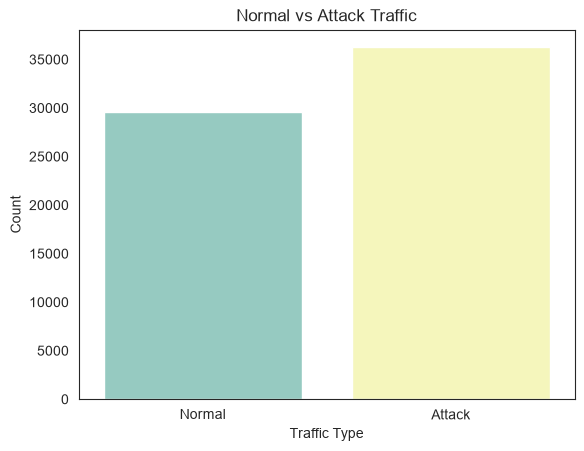

In [97]:
sns.countplot(data=df, x='label', hue='label', legend=False)

plt.xticks([0, 1], ['Normal', 'Attack'])
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.title('Normal vs Attack Traffic')
plt.savefig('fig/n_vs_a', dpi=300, bbox_inches='tight')
plt.show()

In [98]:
class_counts = df['label'].value_counts()
class_freq = df['label'].value_counts(normalize=True) * 100

print(f"Safe Normal Traffic (0): {class_counts[0]} ({class_freq[0]:.2f}%)")
print(f"Malicious Attack (1): {class_counts[1]} ({class_freq[1]:.2f}%)")

Safe Normal Traffic (0): 29600 (44.94%)
Malicious Attack (1): 36265 (55.06%)


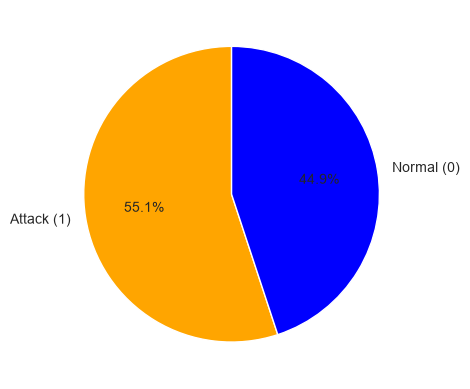

In [99]:
plt.pie(class_counts, labels=['Attack (1)', 'Normal (0)'], autopct='%1.1f%%', colors=['orange','blue'], startangle=90)
plt.savefig('fig/pie.png', dpi=300, bbox_inches='tight')
plt.show()

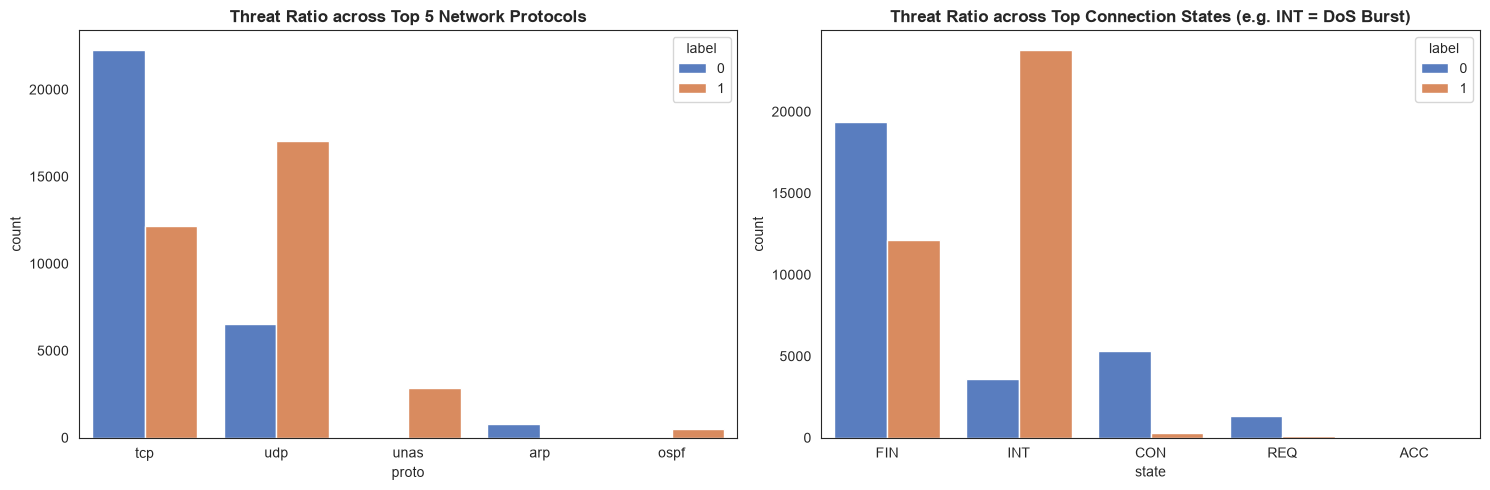

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_protos = df['proto'].value_counts().head(5).index
proto_df = df[df['proto'].isin(top_protos)]
sns.countplot(data=proto_df, x='proto', hue='label', ax=axes[0],palette='muted')
axes[0].set_title("Threat Ratio across Top 5 Network Protocols", fontsize=12, fontweight='bold')

state_df = df[df['state'].isin(df['state'].value_counts().head(5).index)]
sns.countplot(data=state_df, x='state', hue='label', ax=axes[1],palette='muted')
axes[1].set_title("Threat Ratio across Top Connection States (e.g. INT = DoS Burst)", fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig('fig/threat_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

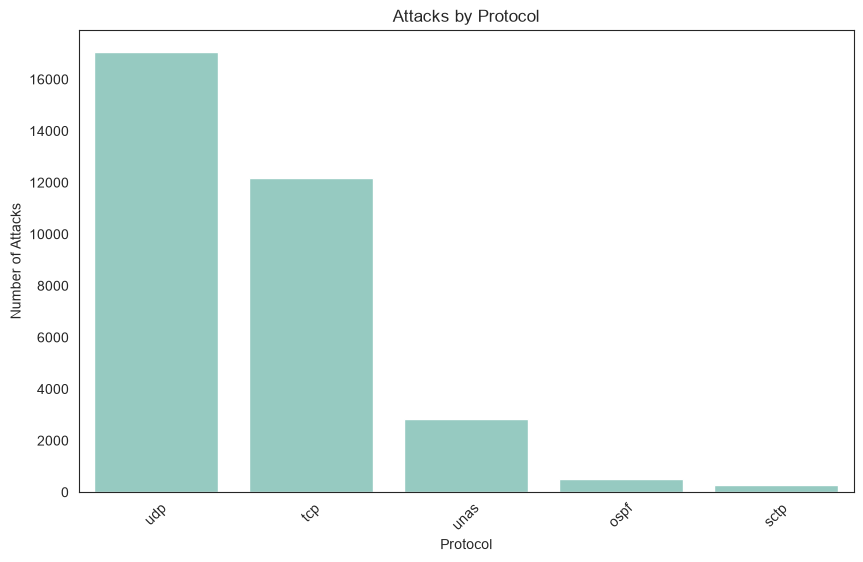

In [101]:
plt.figure(figsize=(10, 6))

attack_protocol = (
    df[df["label"] == 1]["proto"]
    .value_counts().head(5)
)

sns.barplot(
    x=attack_protocol.index,
    y=attack_protocol.values
)

plt.title("Attacks by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45)

plt.savefig('fig/attacks_vs_protocol.png', dpi=300, bbox_inches='tight')
plt.show()

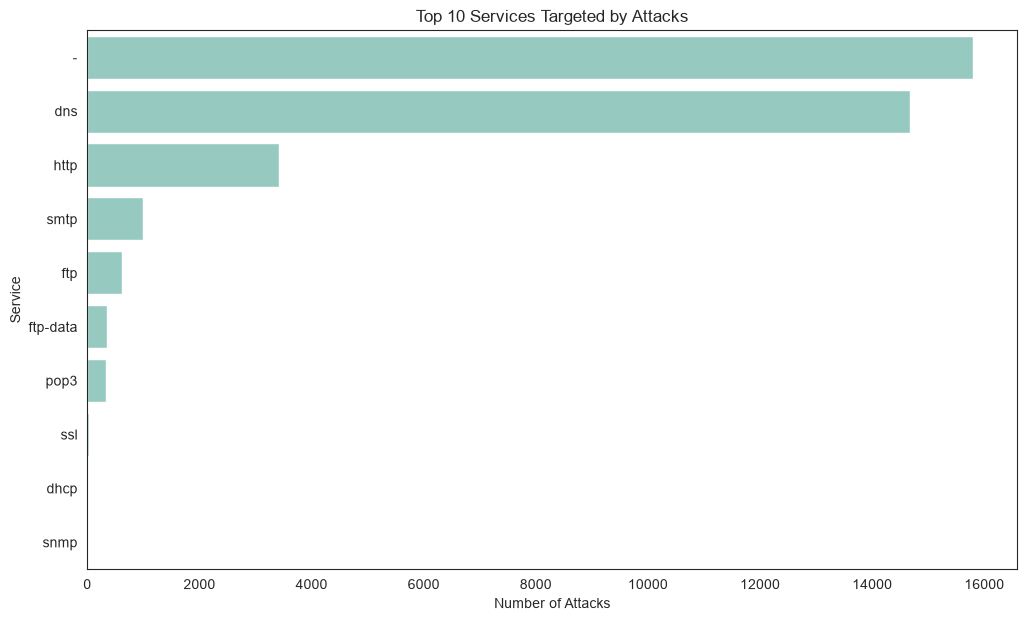

In [102]:
plt.figure(figsize=(12, 7))

attack_service = (
    df[df["label"] == 1]["service"]
    .value_counts()
    .head(10)
)

sns.barplot(
    x=attack_service.values,
    y=attack_service.index
)

plt.title("Top 10 Services Targeted by Attacks")
plt.xlabel("Number of Attacks")
plt.ylabel("Service")

plt.savefig('fig/top_10_service.png', dpi=300, bbox_inches='tight')
plt.show()

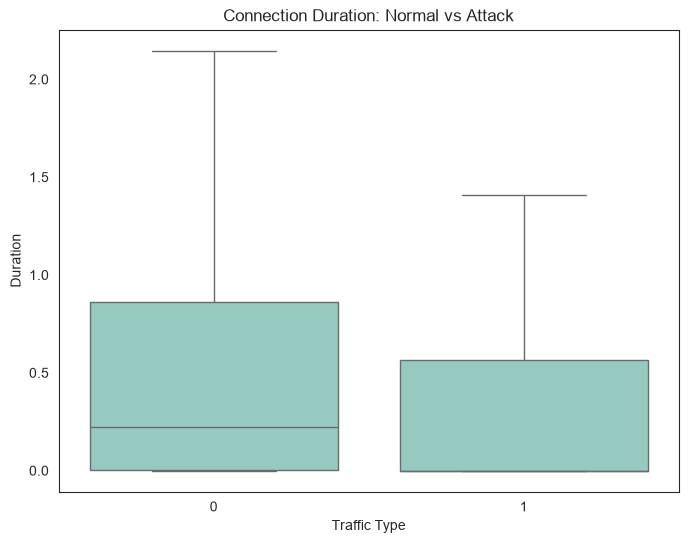

In [103]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="label",
    y="dur",
    showfliers=False
)

plt.title("Connection Duration: Normal vs Attack")
plt.xlabel("Traffic Type")
plt.ylabel("Duration")

plt.savefig('fig/connection_duration.png', dpi=300, bbox_inches='tight')
plt.show()

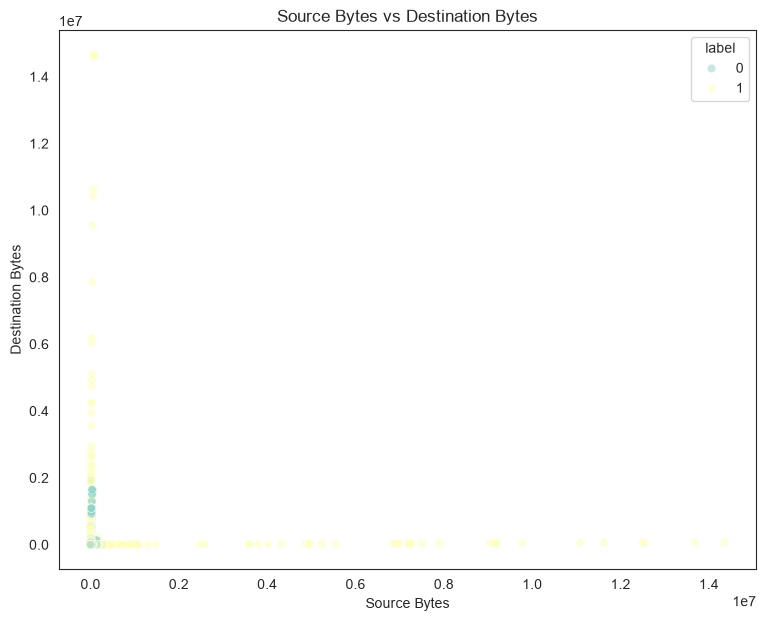

In [104]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x="sbytes",
    y="dbytes",
    hue="label",
    alpha=0.5
)

plt.title("Source Bytes vs Destination Bytes")
plt.xlabel("Source Bytes")
plt.ylabel("Destination Bytes")

plt.savefig('fig/sb_vs_db.png', dpi=300, bbox_inches='tight')
plt.show()

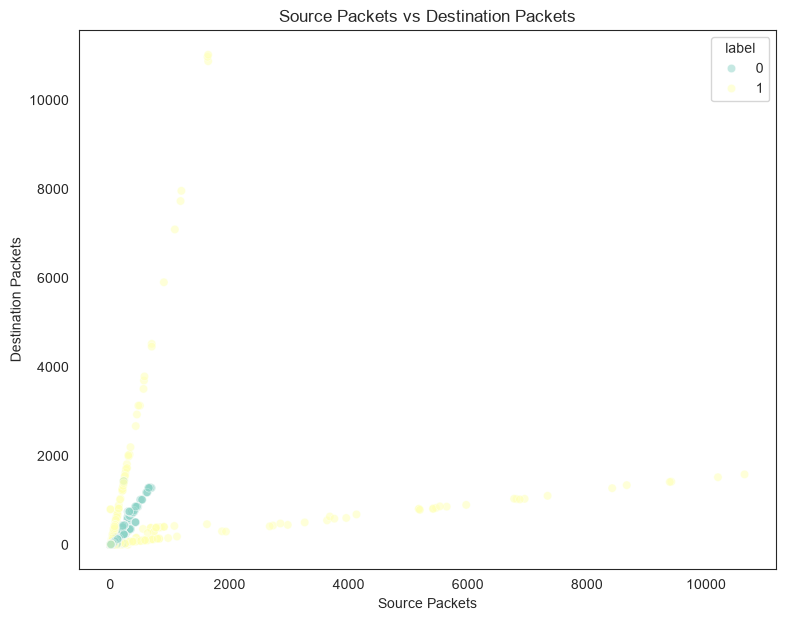

In [105]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x="spkts",
    y="dpkts",
    hue="label",
    alpha=0.5
)

plt.title("Source Packets vs Destination Packets")
plt.xlabel("Source Packets")
plt.ylabel("Destination Packets")

plt.savefig('fig/source_packets_vs_destination_packets.png', dpi=300, bbox_inches='tight')
plt.show()

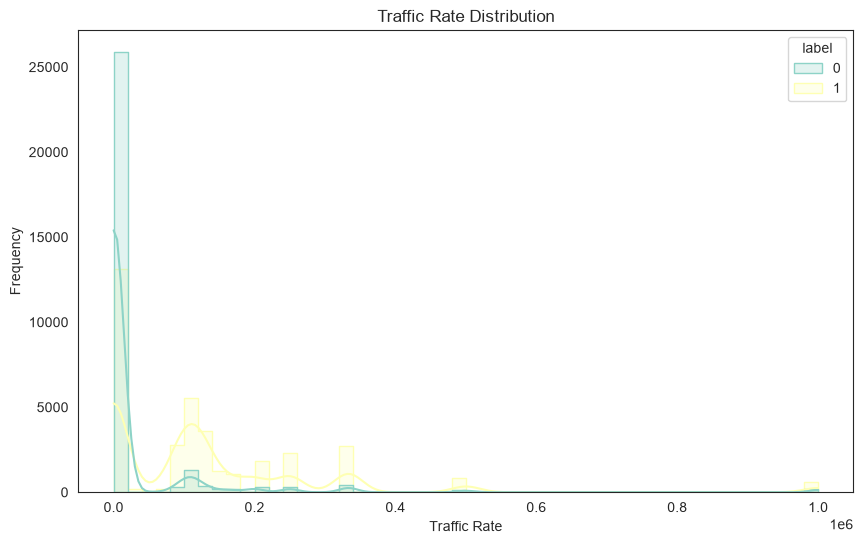

In [106]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="rate",
    hue="label",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Traffic Rate Distribution")
plt.xlabel("Traffic Rate")
plt.ylabel("Frequency")

plt.savefig('fig/traffic_rate_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [107]:
numeric_df = df.select_dtypes(include="number")

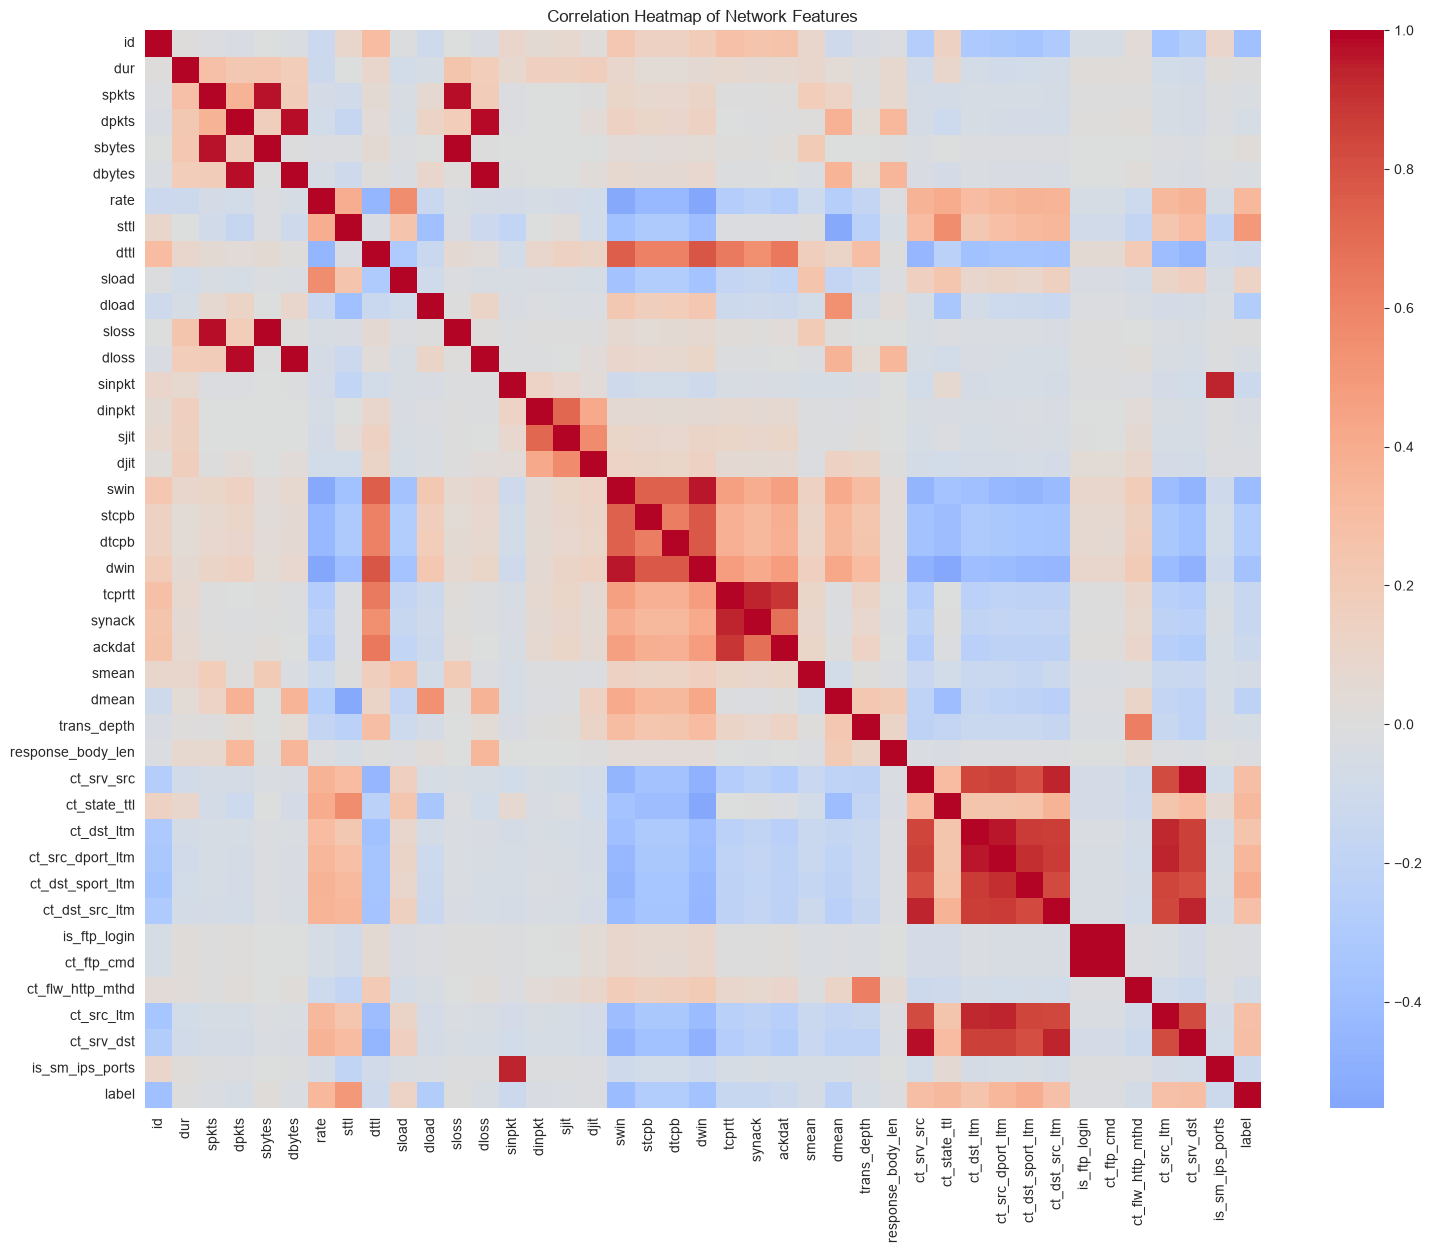

In [108]:
plt.figure(figsize=(18, 14))

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Network Features")

plt.savefig("fig/correlation.png", dpi=300, bbox_inches="tight")
plt.show()

# Loading Testing Set

In [109]:
test_df = pd.read_csv('data/test.csv')

In [110]:
train_df_encoded = df.copy()
test_df_encoded = test_df.copy()

# Encoding The data using LabelEncoder

In [111]:
from sklearn.preprocessing import LabelEncoder, RobustScaler

In [112]:
cat_cols = ['proto','state','service']

In [113]:
num_cols = [col for col in df.columns if col not in cat_cols]

In [114]:
print("Numerical Columns : ", num_cols)
print()
print("Categorical Columns : ", cat_cols)

Numerical Columns :  ['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'label']

Categorical Columns :  ['proto', 'state', 'service']


In [115]:
encoders = {}

for c in cat_cols:
    print(c)
    le = LabelEncoder()
    le.fit(train_df_encoded[c].astype(str))
    train_df_encoded[c] = le.transform(train_df_encoded[c].astype(str))
    test_df_encoded[c] = test_df_encoded[c].astype(str).apply(
        lambda x: int(le.transform([x])[0]) if x in le.classes_ else -1
    )
    encoders[c] = le
    print(f"Encoded '{c}': {len(le.classes_)} unique categories")

Encoded 'service': 13 unique categories


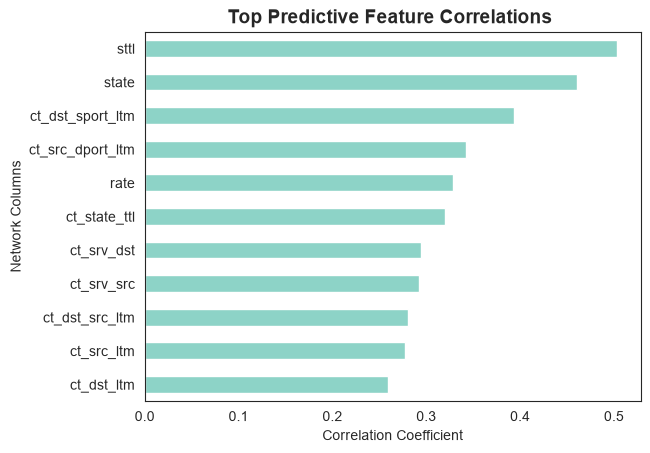

In [116]:
correlations = train_df_encoded.drop(columns=['id']).corr()['label'].drop('label').sort_values(ascending=False)

correlations.head(11).plot(kind='barh')
plt.title("Top Predictive Feature Correlations ", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient")
plt.ylabel("Network Columns")
plt.gca().invert_yaxis()
plt.savefig(
    "fig/top_11_features.png",
    bbox_inches='tight', )
plt.show()

top_11_features = correlations.head(11).index

In [117]:
top_11_features

Index(['sttl', 'state', 'ct_dst_sport_ltm', 'ct_src_dport_ltm', 'rate',
       'ct_state_ttl', 'ct_srv_dst', 'ct_srv_src', 'ct_dst_src_ltm',
       'ct_src_ltm', 'ct_dst_ltm'],
      dtype='str')